## 📌 미션 개요

* **목적**: 2015.07.01 \~ 2017.08.31 기간 동안 **Resort Hotel**과 **City Hotel** 예약 데이터를 분석.
* **역할**: 호텔 관리인 입장에서 **예약 취소에 영향을 주는 요인**을 찾고, **취소율을 줄이기 위한 아이디어** 제시.
* **분석 주제**

  1. 어떤 조건에서 예약 취소가 빈번한가?
  2. 예약 취소와 관련 있는 주요 요소는 무엇인가?
  3. 예약 취소율 개선 방법은?

---

## 📊 데이터 특징

* 원본: Kaggle "Hotel Booking Demand Datasets"에서 코드잇이 일부 수정.
* 구성: 2년 2개월간의 **예약·취소 이력**
* 단위: 예약 단위(개별 고객 예약 건별 데이터)

---

## 📑 주요 컬럼 설명 (중요도 순으로 요약)

| 컬럼명                                                       | 의미                                   |
| --------------------------------------------------------- | ------------------------------------ |
| **hotel**                                                 | 호텔 종류: Resort Hotel / City Hotel     |
| **is\_canceled**                                          | 예약 취소 여부 (1=취소, 0=취소 아님)             |
| **lead\_time**                                            | 예약일 \~ 도착일 사이 일수                     |
| **arrival\_date\_year/month/week\_number/day\_of\_month** | 도착 날짜 관련 변수                          |
| **stays\_in\_weekend\_nights**                            | 주말 숙박일 수                             |
| **stays\_in\_week\_nights**                               | 주중 숙박일 수                             |
| **adults / children / babies**                            | 투숙 인원 구성                             |
| **meal**                                                  | 식사 옵션 (SC, BB, HB, FB)               |
| **country**                                               | 고객 국적 (ISO 코드)                       |
| **market\_segment / distribution\_channel**               | 예약 경로, 채널                            |
| **is\_repeated\_guest**                                   | 재방문 고객 여부                            |
| **previous\_cancellations**                               | 이전 취소 건수                             |
| **previous\_bookings\_not\_canceled**                     | 이전 비취소 건수                            |
| **reserved\_room\_type / assigned\_room\_type**           | 예약한 객실 vs 실제 배정 객실                   |
| **booking\_changes**                                      | 예약 변경 횟수                             |
| **days\_in\_waiting\_list**                               | 대기자 명단 일수                            |
| **required\_car\_parking\_spaces**                        | 요청 주차 공간 수                           |
| **total\_of\_special\_requests**                          | 특별 요청 수                              |
| **reservation\_status**                                   | 최종 상태 (Canceled, Check-Out, No-Show) |
| **reservation\_status\_date**                             | 최종 상태가 확정된 날짜                        |

---

## 🛠 제출 방식

* **파일명**: `미션2_{팀명}_{성함}.ipynb`
* **제출 위치**: 구글 드라이브 > 결과물 제출 폴더 > 미션02 폴더
* **형식**: Colab Notebook

In [ ]:
# 한글 설치 해보자이

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

!apt-get update -qq
!apt-get install fonts-nanum* -qq

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings(action='ignore')

path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # 나눔 고딕
font_name = fm.FontProperties(fname=path, size=10).get_name() # 기본 폰트 사이즈 : 10
plt.rc('font', family=font_name)

fm.fontManager.addfont(path)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
# 코랩 구글드라이브
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1. 기본 라이브러리 및 데이터 불러오기
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/02_AI강의/03_Sprint-Mission/Mission No2/hotel_data_modified.csv')

# 1. 데이터 입력 및 분석

In [ ]:
df.info()                        # 열의 전체 정보
print("\n\n\n\n")
print(f"결측치 결과입니다\n{df.isna().sum()}")      # 결측치

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0
children,119386.0,0.103890,0.398561,0.0,0.0,0.0,0.0,10.0
babies,119390.0,0.007949,0.097436,0.0,0.0,0.0,0.0,10.0



# 📊 호텔 예약 데이터 1차 탐색 결과

## 1. 데이터 개요

* 전체 크기: **119,390행 × 29열**
* 변수 유형:
  * 숫자형(int/float): 19개
  * 범주형(object): 10개
---

## 2. 결측치 현황

| Column     | 결측치 수   | 비고                       |
| ---------- | ------- | ------------------------ |
| `children` | 4       | 매우 적은 수준                 |
| `country`  | 488     | 일부 국가 정보 누락              |
| `agent`    | 16,340  | 결측치가 아니라고 확인 (아래 참조)            |
| `company`  | 112,593 | 결측치가 아니라고 확인 (아래 참조) |
| 나머지        | 0      | 결측치 없음                   |

➡️ https://pmc.ncbi.nlm.nih.gov/articles/PMC6297060/
- The PMS assured no missing data exists in its database tables. However, in some categorical variables like Agent or Company, “NULL” is presented as one of the categories. This should not be considered a missing value, but rather as “not applicable”. For example, if a booking “Agent” is defined as “NULL” it means that the booking did not came from a travel agent.
- 값이 없는 사람은 travel agent 없이 여행 온 것을 의미함.

➡️ 결론: `company`는 결측이 심각해 분석 변수에서 제외 가능성이 큼.
`agent`도 결측이 많아 전처리 방식 필요.


---

## 3. 주요 변수 통계 요약

### (1) 예약 및 취소

* `is_canceled`: 평균 **0.37**  ➡️ 전체 예약 중 약 37% 취소
* `lead_time`: 평균 104일, 최대 737일  ➡️ lead_time이 너무 큰 선결제가 다수 존재 ➡️ 데이터가 잘 못 되었을 수 있음.
* `arrival_date_year`: 2015\~2017년 분포
* `arrival_date_month`: 8월 예약이 가장 많음. (월별 시즌성 분석 가능)
* `arrival_date_day_of_month`: 평균 15.8일 ➡️ 월에 date 상관없이 골고루 도착함.
* `stays_in_weekend_nights`: 평균 0.93박 (최대 19박)
* `stays_in_week_nights`: 평균 2.5박 (최대 50박)  ➡️ 주중 숙박 비중이 주말보다 높음
* `stays_in_weekend_nights`+`stays_in_week_nights`:
  ➡️ 둘다 0인 데이터가 있음. 뭐고? : 5조 디스커션 결과, 대실일 수 있음.

* `adults`: 평균 1.86명, 중앙값 2명
* `children`: 평균 0.10명 (최대 10명)
* `babies`: 평균 0.008명 (최대 10명)
  ➡️ 대부분 성인 위주의 예약

* `is_repeated_guest`: 약 3%만 반복 고객 ➡️ 대부분 신규 고겍
* `previous_cancellations`: 평균 0.087회 (최대 26회)
* `previous_bookings_not_canceled`: 평균 0.137회 (최대 72회?)
  ➡️ 과거 취소 경험이 많은 고객 존재

* `booking_changes`: 평균 0.22회, 최대 21회  ➡️ 이게 가능한 일일까?
* `days_in_waiting_list`: 평균 2.32일, 최대 391일  ➡️ 일부 극단적 대기 (이것도 불가능?, 상줌님 디스커션)

* `total_of_special_requests`: 평균 0.57건, 최대 5건 (강사님 강의, 바다뷰, 고층, 트윈침대, 등 했을때 5건 가능)

* `required_car_parking_spaces`: 평균 0.06, 대부분 0 → 극히 일부만 사용
* `agent`: 평균 86.7, 중앙값 14 (숫자의 의미는 없음), 103,050 명 (86%) 가 agent 이용해 결제.
* `company`: 평균 189, 중앙값 179 (숫자의 의미는 없음), 6797 (5%) 만 company로 결제.


---

## 4. 분석을 위한 인사이트 (조별 디스커션 이후 수정)

* **예측 변수 후보**:

  * 과거 취소 경험(`previous_cancellations`)
  * 예약 변경(`booking_changes`)
  * 특별 요청(`total_of_special_requests`)
  * 숙박 패턴(`stays_in_weekend_nights`, `stays_in_week_nights`)
   * 두개 합치기, 둘 다 0인 값? 확인해봐
  * `adults`, `children`, `babies` -> 가족여행에 대해 변수를 세울 수 있음.
  * `previous_cancellations` -> 이전 취소목록을 비교해볼 수도 있음.
  * `Country`나라별 트렌드가 있을까?
  * `required_car_parking_spaces` -> Right-skewed 되어있다.

* **제외 가능 변수**: `company` (결측률 94%↑)
* **전처리 필요 변수**:
  * `days_in_waiting_list`, `lead_time` (조하나 강사님 강의: 극단값 처리 필요할수도 있음.)

# 2. 이상치, 결측치, 중복값 분석

In [ ]:
# 이상치를 찾아보자
#### total = df.shape[0]
#### outliers_count = df[((df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0))].shape[0]
#### print ("이상치 개수:", outliers_count)
#### print("전체 대비 비율:", outliers_count / total * 100, "%")

## 1. (이상치 o) 숙박자가 없는 경우, 이상치로 간주 (0.15%)
df = df[~((df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0))]

## 2. (이상치 x) `previous_bookings_not_canceled` (최대 72회)? 70건 이상 -> 여행사 대신 예매 가능할 듯 (확실한 증거가 없으면 이상치 아니라고 간주)

## 3. (이상치 o) `days_in_waiting_list`, `lead_time` (최대 391일, 737일) -> 1년치가 넘어가면, 이는 이상치로 간주(AirBnB, Hotel Hilton, Agoda 1년 이상 예약은 불가), 0.10% (1번과 겹치는 것도 100건 이상)
df = df[~((df['days_in_waiting_list'] > 365) | (df['lead_time'] == 365))]
## 4  (이상치 x) `booking_changes` (최대 21회) 등 극단값 존재 -> 여행사가 예약시 가능함.
print(df.shape[0])

119085


In [ ]:
#중복값, 결측치 찾아보자

duplicated_rows = df[df.duplicated()].T
print(duplicated_rows.shape[0])
duplicated_rows.head()## 중복치는 같은 예약일에 같은 조건으로 들어온 사람이 있을 수 있으므로, 중복치가 아니라고 판단.

32


,5,22,43,138,200,219,256,261,353,372,...,119315,119327,119342,119347,119348,119349,119352,119353,119354,119373
hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,...,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel
is_canceled,0,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
lead_time,14,72,70,5,0,1,91,30,98,40,...,230,186,63,63,63,186,63,63,63,175
arrival_date_year,2015,2015,2015,2015,2015,2015,2015,2015,2015,2015,...,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017
arrival_date_month,July,July,July,July,July,July,July,July,July,July,...,August,August,August,August,August,August,August,August,August,August


# 3. 데이터 시각화 및 상관관계 분석

In [ ]:
## 예약 취소 건수 확인
df['is_canceled'].value_counts()

,count
is_canceled,
0,74994
1,44091


In [ ]:
## 예약 상태 확인
df['reservation_status'].value_counts()

### is_canceled ==0 → Check-out
### is_canceled ==1 → Canceled+No-Show

,count
reservation_status,
Check-Out,74994
Canceled,42885
No-Show,1206


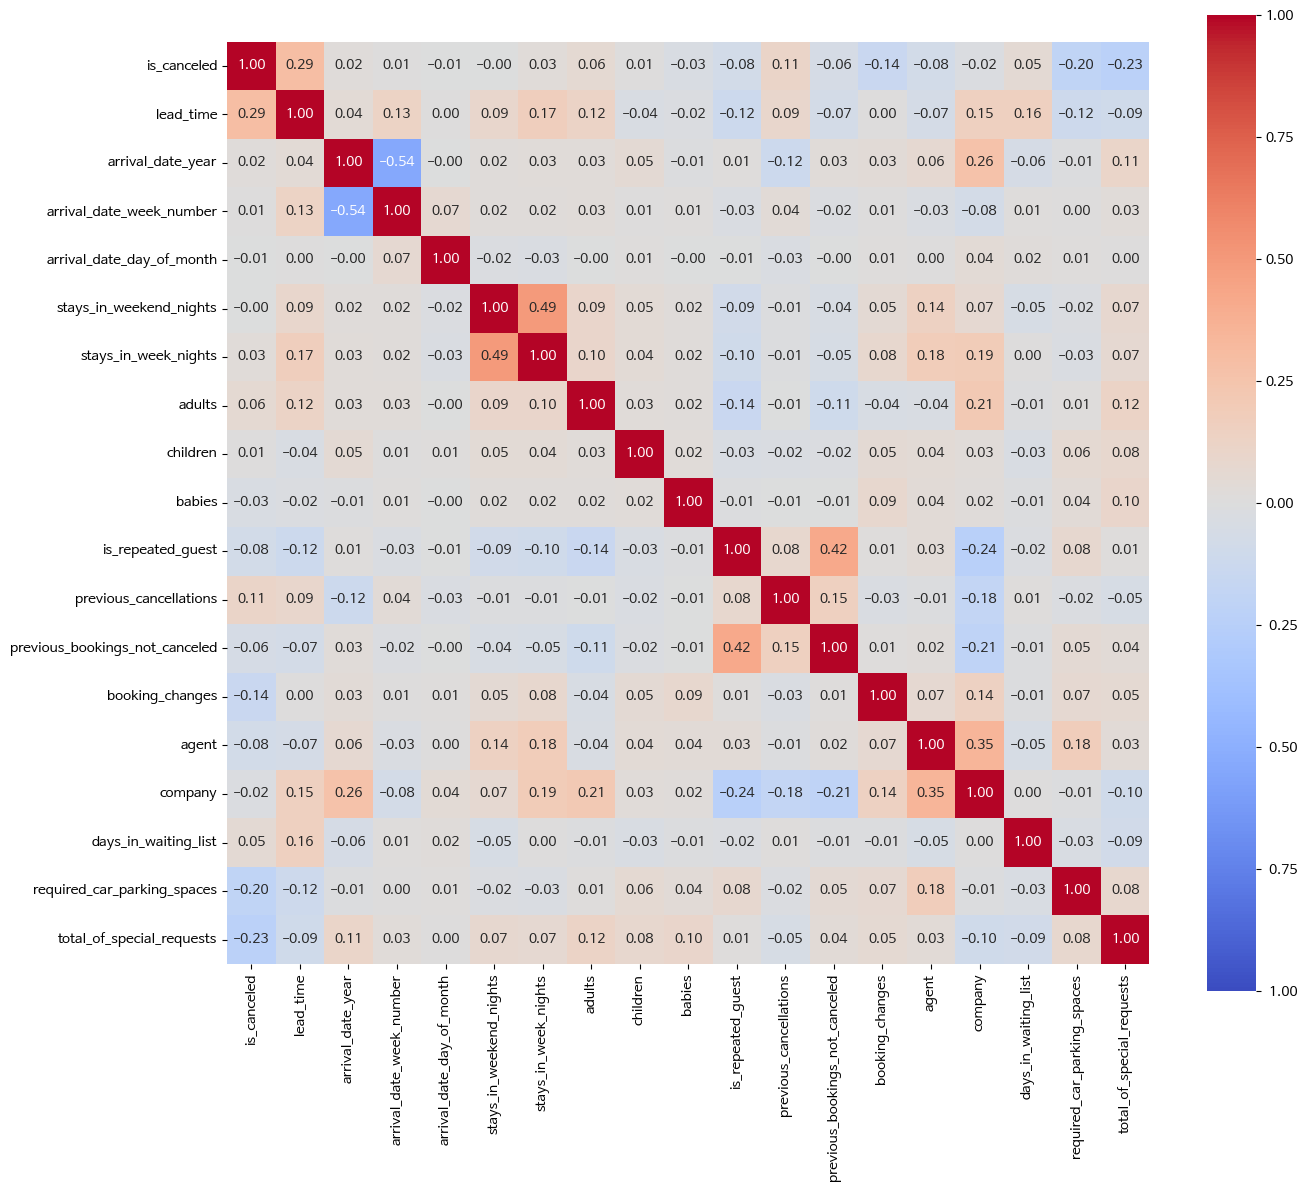

In [ ]:
# 상관관계 분석
##   수치형 변수 간 상관계수 (`.corr()`)
##  범주형 변수별 취소율 비교 (groupby)

num_df = df.select_dtypes(include="number")  # 수치형 컬럼만 선택
corr = num_df.corr(numeric_only=True)          # 상관계수 행렬

plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5
)
plt.tight_layout()
plt.show()

# 히트맵 수치가 많아서 잘 안보임. 수치 데이터 및 중요한 데이터만 다시 히트맵으로 뽑아보자.

In [1]:
## 값의 의미.
### 약 0.25 이상: 꽤 의미 있는 단일 신호 (단변량 기준)
### 0.10 ~ 0.25: 약한 신호지만 대규모 데이터에선 유의할 수 있음
### 0.00 ~ 0.10: 매우 약함 (다른 변수와 함께 보거나 구간화해서 봐야 함)

## 상관관계 0.1 이상 뽑아 다시 히트맵 작성.
num_df = df.select_dtypes(include="number")
corr = num_df.corr()
target_corr = corr['is_canceled'].drop('is_canceled')
important_corr = target_corr[abs(target_corr) >= 0.1].index
cols = ['is_canceled'] + important_corr.tolist()

print(important_corr)
print(important_corr.tolist())
print(cols)

NameError: name 'df' is not defined

In [ ]:
# 히트맵으로 중요데이터만 다시 뽑자

sns.heatmap(corr.loc[cols, cols], annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.show()

# annot=True - 칸 안에 숫자
# cmap = 낮은값 파랑, 높은값 빨강
# annot=True일 때 셀 안 숫자를 소수 둘째 자리까지 표기.

## 상관관계 분석 (is_canceled 와 연관도가 있다고 의심할 수 있는 컬럼?)
- lead_time
- previous_cancellations
- booking_changes
- required_car_parking_spaces
- total_special_requests

In [ ]:
#lead_time, required_car_parking_spaces, total_of_special_requests가 상관관계가 큼
#조금 다르게 상관관계를 더 잘 볼 수 있는 방법 없을까? (히스토그램)

plt.figure(figsize=(18, 4))   # 그래프 크기 15인치 × 세로 8인치

for i, col in enumerate(important_corr, 1):   # important_corr 리스트의 변수명을 하나씩 꺼내면서 번호(i, 1부터 시작)와 변수명(col) 얻기
    plt.subplot(1, 5, i)   # 2행 3열 격자로 나누고, i번째 위치에 subplot(그래프 자리) 배치

    sns.histplot(          # seaborn의 히스토그램(histplot)으로 변수 분포를 시각화
        data=df,           # 데이터는 df에서 가져옴
        x=col,             # col 변수값을 X축에 배치
        hue='is_canceled', # is_canceled 값(취소 여부)에 따라 색깔 다르게 표시
        kde=False,         # 커널밀도(kde) 곡선은 그리지 않음 (잘 안보임)
        stat="density",    # y축을 건수(count)가 아닌 확률밀도(density)로 설정
        bins=30            # 히스토그램 구간(bin)을 30개로 나눔
    )

    plt.title(f"{col} (유지0 vs 취소1)")  # subplot 제목: 변수명 + “분포 (취소 vs 유지)”
    plt.xlabel(col)                          # X축 라벨은 해당 변수명
    plt.ylabel("비율")                       # Y축 라벨은 "비율"이라고 표기

plt.tight_layout()   # subplot 간의 여백 자동 조정 → 글자나 그래프가 겹치지 않도록 정리
plt.show()           # 지금까지 만든 figure와 subplot들을 실제 화면에 출력

#3-1 Lead_time (0 은 ㄱㄱ , 1은 취소)


In [2]:
df["lead_time_bin"] = pd.cut(df["lead_time"], bins=range(0, 365, 30))

agg = (df.groupby("lead_time_bin", observed=True)["is_canceled"].mean().reset_index())
agg["bin_label"] = agg["lead_time_bin"].astype(str)

sns.barplot(data=df, x="lead_time_bin", y="is_canceled", errorbar=None)
sns.lineplot(data=agg, x="bin_label", y="is_canceled", marker="o")
plt.title("Lead Time vs. 예약 취소율")
plt.ylabel("취소율")
plt.ylim(0, 1)  # 취소율로 y축을 설정하기 위해 필요
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

NameError: name 'pd' is not defined

#### lead_time: 예약과 체크인 사이 기간이 길수록 취소될 확률이 높아진다. (고민할 시간이 많아짐?)
    # 결론 1 (아이디어): 얼마 남지 않은 호텔의 경우, 할인을 더 줄래? (그럼 취소 안하고, 팔리는게 많아짐)


# 3-2 Previous_cancellations (0 은 ㄱㄱ , 1은 취소)

In [ ]:
# previous_cancellations 시각화
repeat_cancel = df.copy()
repeat_cancel['prev_cancel_group'] = repeat_cancel['previous_cancellations'].apply(lambda x: '이전 취소 X' if x == 0 else '이전 취소 O')

# 그룹별 평균 취소율 계산
# - 0회     → '이전 취소 X (0회)'
# - 1회 이상 → '이전 취소 O (1회 이상)'
repeat_cancel = repeat_cancel.groupby('prev_cancel_group')['is_canceled'].mean().reset_index()
repeat_cancel.columns = ['고객 유형', '평균 취소율']

# 시각화
sns.barplot(data=repeat_cancel, x='고객 유형', y='평균 취소율')
plt.title('이전 취소 여부에 따른 평균 예약 취소율')
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.show()


#### previous_cancellations: 신규고객의 평균취소율이 낮다 (고민할 시간이 많아짐?)
    # 결론 2 (아이디어): 이전에 취소하지 않는 사람들에게 더 많은 프로모션을 준다. 신규고객들은 취소하지 않으니까!


# 3-3. Booking_changes

In [ ]:
# booking_changes 시각화
repeat_cancel = df.copy()
repeat_cancel['book_changes_group'] = repeat_cancel['booking_changes'].apply(lambda x: '바꾼 적 없음' if x == 0 else '자주 변경')

# 그룹별 평균 취소율 계산
# - 0회     → '바꾼적 없음 (0회)'
# - 1회 이상 → '자주 변경 (1회 이상)'
repeat_cancel = repeat_cancel.groupby('book_changes_group')['is_canceled'].mean().reset_index()
repeat_cancel.columns = ['고객 유형', '평균 변경율']

# 시각화
sns.barplot(data=repeat_cancel, x='고객 유형', y='평균 변경율')
plt.title('이전 취소 여부에 따른 평균 예약 취소율')
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.show()


#### Booking changes: 자주 변경한 고객의 평균취소율이 낮다 (고민할 시간이 많아짐?)
    # 결론 3 (아이디어): 변경할 수 있는 기간을 더 늘려서, 변경할 수 있는 사람들을 더 많이 만든다.


# 3-4. Required_car_paring_spaces

In [ ]:
cancel_rate_by_parking = df.groupby("required_car_parking_spaces")["is_canceled"].mean().reset_index()

sns.barplot(data=cancel_rate_by_parking, x="required_car_parking_spaces", y="is_canceled")
plt.xlabel("주차 공간 수")
plt.ylabel("취소율")
plt.title("주차 공간 요구에 따른 취소율")
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.show()

#### cancel_rate_by_parking: 차 있는 사람 취소 안해!
    # 결론 4 (아이디어): 그럼 호텔들에게 이 정보를 알리고 미포함된 주차장이 있다면, 이 표시를 조금 더 늘리게 할것.





# 3-5. total_of_special_requests

In [ ]:
special_cancel = df.groupby('total_of_special_requests')['is_canceled'].mean().reset_index()
special_cancel.columns = ['요청 수', '평균 취소율']

# 시각화
plt.figure(figsize=(5, 3))
sns.barplot(data=special_cancel, x='요청 수', y='평균 취소율')
plt.title('특별 요청 수에 따른 평균 예약 취소율')
plt.show()

#### total_of_special_requests: 특별요청이 많을수록 취소율이 낮다 (까다로운 사람들은 선택후 바꾸지 않는다.)
    # 결론 5 (아이디어): 숙박 신청 시에, 특별요청을 할 수 있는 것들을 넣어두고, 다른 호텔들보다 까다롭게 숙박 신청을 하게 하면 취소를 안하는 비율이 올라갈 수도?!

# 4. 추가적인 결론

 1. 새로운 KPI 도출
  - 결론 5 (아이디어): 충성고객들을 확보하기 위해, 다음과 같은 KPI를 만들 수 있음.
  - KPI = Total_of_special_requests - previous_cancellations

 2. 문자 데이터는 어떻게 파악할거야? (실수?)

In [3]:
# 실수 1 - 문자데이터는 어쩔거야?
num_df = df.select_dtypes(include="number")  # 수치형 컬럼만 선택
obj_df = df.select_dtypes(include="object")  # object 컬럼만 선택
float_df = df.select_dtypes(include="float64")  # float64 컬럼만 선택

print(num_df.columns)
print(obj_df.columns)

NameError: name 'df' is not defined